In [1]:
!pip -q install "setuptools<81" tensorflow tensorflow-hub librosa scikit-learn pandas seaborn matplotlib scipy joblib tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Google Colab not detected. If you are running locally, update PROJECT_ROOT below.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/1:1_Arjan_Walia/Vessels")  # Update this if your Drive path is different.
TRAIN_CSV = PROJECT_ROOT / "datasets" / "processed_files" / "wolfset_train.csv"
AUDIO_DIR = PROJECT_ROOT / "datasets" / "25791978"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
EMBEDDING_CACHE_DIR = ARTIFACT_DIR / "yamnet_embeddings_train_5s"
TFHUB_CACHE_DIR = ARTIFACT_DIR / "tfhub_cache"
RESULTS_PATH = ARTIFACT_DIR / "yamnet_cv_results.csv"
SUMMARY_PATH = ARTIFACT_DIR / "yamnet_cv_summary.csv"

TARGET_SAMPLE_RATE = 16000
CLIP_DURATION_SECONDS = 5.0
CV_FOLDS = 5
BATCH_SIZE = 16
LEARNING_RATES = [1e-4, 3e-4, 1e-3]
EPOCH_OPTIONS = [10, 20, 30]
SEED = 42

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

assert TRAIN_CSV.exists(), f"Could not find: {TRAIN_CSV}"
assert AUDIO_DIR.exists(), f"Could not find: {AUDIO_DIR}"
print(PROJECT_ROOT)

/content/drive/MyDrive/1:1_Arjan_Walia/Vessels


In [4]:
import json
import os
import random
from itertools import product
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_hub as hub
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

CLASS_NAME_MAP = {
    1: "4.5hp",
    2: "18hp",
    3: "8hp",
    4: "3.6hp",
    5: "Electric",
}


def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def load_split_dataframe(csv_path: Path, audio_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path).copy()
    df["label"] = df["label"].astype(int)
    df["audio_path"] = df["filename"].map(lambda name: str((audio_dir / name).resolve()))
    missing = [name for name, path in zip(df["filename"], df["audio_path"]) if not Path(path).exists()]
    if missing:
        raise FileNotFoundError(f"Missing {len(missing)} audio files. First few: {missing[:5]}")
    return df.reset_index(drop=True)


def load_waveform(audio_path: str, target_sample_rate: int = 16000, clip_duration_seconds: float = 5.0) -> np.ndarray:
    waveform, _ = librosa.load(audio_path, sr=target_sample_rate, mono=True, duration=clip_duration_seconds)
    waveform = waveform.astype(np.float32)
    peak = np.max(np.abs(waveform))
    if peak > 0:
        waveform = waveform / peak
    return waveform


def load_yamnet_model(cache_dir: Path):
    cache_dir.mkdir(parents=True, exist_ok=True)
    os.environ["TFHUB_CACHE_DIR"] = str(cache_dir)
    return hub.load("https://tfhub.dev/google/yamnet/1")


def extract_yamnet_embedding(audio_path: str, yamnet_model, target_sample_rate: int = 16000, clip_duration_seconds: float = 5.0) -> np.ndarray:
    waveform = load_waveform(audio_path, target_sample_rate=target_sample_rate, clip_duration_seconds=clip_duration_seconds)
    _, embeddings, _ = yamnet_model(waveform)
    return np.mean(embeddings.numpy(), axis=0).astype(np.float32)


def build_embedding_matrix(
    metadata: pd.DataFrame,
    yamnet_model,
    cache_dir: Path,
    target_sample_rate: int = 16000,
    clip_duration_seconds: float = 5.0,
) -> tuple[pd.DataFrame, np.ndarray]:
    cache_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    embeddings = []

    for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="YAMNet embeddings"):
        cache_name = f"{Path(row['filename']).stem}_sr{target_sample_rate}_{clip_duration_seconds:g}s.npy"
        cache_path = cache_dir / cache_name

        if cache_path.exists():
            embedding = np.load(cache_path)
        else:
            embedding = extract_yamnet_embedding(
                audio_path=row["audio_path"],
                yamnet_model=yamnet_model,
                target_sample_rate=target_sample_rate,
                clip_duration_seconds=clip_duration_seconds,
            )
            np.save(cache_path, embedding)

        rows.append(row)
        embeddings.append(embedding.astype(np.float32))

    return pd.DataFrame(rows).reset_index(drop=True), np.vstack(embeddings).astype(np.float32)


def build_classifier(input_dim: int, num_classes: int, learning_rate: float, dropout_rate: float = 0.30) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate / 2.0),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def compute_class_weight_dict(y_encoded: np.ndarray) -> dict[int, float]:
    classes = np.unique(y_encoded)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_encoded)
    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}

In [5]:
set_global_seed()

train_df = load_split_dataframe(TRAIN_CSV, AUDIO_DIR)
display(train_df[["filename", "label"]].head())
display(train_df["label"].value_counts().sort_index().rename("count").to_frame())

yamnet_model = load_yamnet_model(TFHUB_CACHE_DIR)
train_df, X = build_embedding_matrix(
    metadata=train_df,
    yamnet_model=yamnet_model,
    cache_dir=EMBEDDING_CACHE_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    clip_duration_seconds=CLIP_DURATION_SECONDS,
)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_df["label"].to_numpy())
class_names = [CLASS_NAME_MAP.get(int(value), f"Class {value}") for value in label_encoder.classes_]

print("Embedding matrix shape:", X.shape)
print("Encoded classes:", dict(zip(label_encoder.classes_, class_names)))


,filename,label
0,A02000T04N00.wav,2
1,A20000T02N00.wav,1
2,A20000T00N04x02.wav,1
3,A00010T00N00.wav,4
4,A20000T00N08x04.wav,1


,count
label,
1,40
2,13
3,13
4,11
5,8


YAMNet embeddings:   0%|          | 0/85 [00:00<?, ?it/s]

Embedding matrix shape: (85, 1024)
Encoded classes: {np.int64(1): '4.5hp', np.int64(2): '18hp', np.int64(3): '8hp', np.int64(4): '3.6hp', np.int64(5): 'Electric'}


In [6]:
all_rows = []
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

for learning_rate, epochs in product(LEARNING_RATES, EPOCH_OPTIONS):
    print(f"Evaluating learning_rate={learning_rate}, epochs={epochs}")

    for fold_index, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        tf.keras.backend.clear_session()
        set_global_seed(SEED + fold_index)

        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]
        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)

        model = build_classifier(
            input_dim=X_train_scaled.shape[1],
            num_classes=len(label_encoder.classes_),
            learning_rate=learning_rate,
        )

        history = model.fit(
            X_train_scaled,
            y_train_fold,
            epochs=epochs,
            batch_size=BATCH_SIZE,
            verbose=0,
            class_weight=compute_class_weight_dict(y_train_fold),
        )

        val_probabilities = model.predict(X_val_scaled, verbose=0)
        val_predictions = np.argmax(val_probabilities, axis=1)

        all_rows.append({
            "learning_rate": learning_rate,
            "epochs": epochs,
            "fold": fold_index,
            "accuracy": accuracy_score(y_val_fold, val_predictions),
            "macro_f1": f1_score(y_val_fold, val_predictions, average="macro"),
            "weighted_f1": f1_score(y_val_fold, val_predictions, average="weighted"),
            "final_train_loss": float(history.history["loss"][-1]),
            "final_train_accuracy": float(history.history["accuracy"][-1]),
        })

results_df = pd.DataFrame(all_rows).sort_values(by=["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_PATH, index=False)

summary_df = (
    results_df.groupby(["learning_rate", "epochs"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_weighted_f1=("weighted_f1", "mean"),
    )
    .sort_values(by=["mean_macro_f1", "mean_accuracy"], ascending=False)
    .reset_index(drop=True)
)
summary_df.to_csv(SUMMARY_PATH, index=False)
display(summary_df)


Evaluating learning_rate=0.0001, epochs=10


Evaluating learning_rate=0.0001, epochs=20


Evaluating learning_rate=0.0001, epochs=30
Evaluating learning_rate=0.0003, epochs=10
Evaluating learning_rate=0.0003, epochs=20
Evaluating learning_rate=0.0003, epochs=30
Evaluating learning_rate=0.001, epochs=10
Evaluating learning_rate=0.001, epochs=20
Evaluating learning_rate=0.001, epochs=30


,learning_rate,epochs,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_weighted_f1
0,0.0010,20,0.788235,0.089210,0.745625,0.105449,0.779567
1,0.0010,10,0.776471,0.105227,0.719354,0.119808,0.770412
2,0.0010,30,0.776471,0.096657,0.713673,0.119774,0.762648
3,0.0003,30,0.752941,0.105227,0.676425,0.138906,0.747890
4,0.0003,20,0.741176,0.114668,0.674547,0.144428,0.744387
5,0.0003,10,0.705882,0.093008,0.658935,0.128361,0.727654
6,0.0001,30,0.682353,0.098431,0.627947,0.087343,0.694610
7,0.0001,20,0.647059,0.117647,0.598845,0.121018,0.662212
8,0.0001,10,0.505882,0.135422,0.422380,0.078403,0.513585


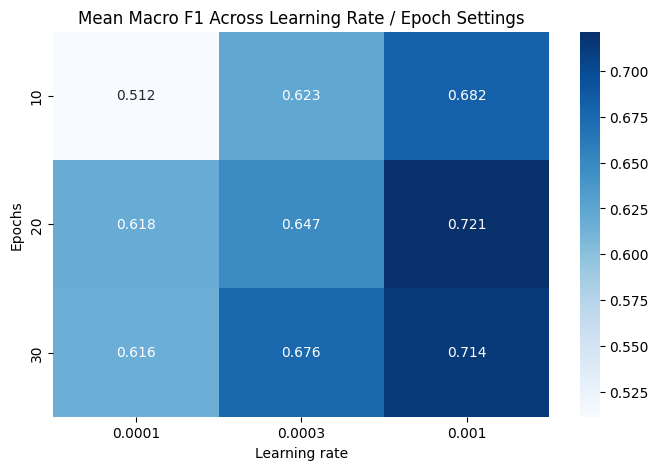

Best configuration based on mean_macro_f1:
{'learning_rate': 0.001, 'epochs': 20.0, 'mean_accuracy': 0.7626315789473683, 'std_accuracy': 0.09456124076410827, 'mean_macro_f1': 0.7212063492063491, 'std_macro_f1': 0.12139202686936545, 'mean_weighted_f1': 0.7466641604010025}


In [ ]:
heatmap_df = summary_df.pivot(index="epochs", columns="learning_rate", values="mean_macro_f1")

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="Blues")
plt.title("Mean Macro F1 Across Learning Rate / Epoch Settings")
plt.xlabel("Learning rate")
plt.ylabel("Epochs")
plt.show()

best_row = summary_df.iloc[0]
print("Best configuration based on mean_macro_f1:")
print(best_row.to_dict())
